In [1]:

# ============================================================
# 0. Imports and unified settings
# ============================================================

from pathlib import Path
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

DATA_PATH = Path("df_base.csv")
OUTPUT_DIR = Path("baseline_feature_expansion_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Paired repeated held-out evaluation, aligned with the later notebooks.
HOLDOUT_SEEDS = list(range(10))
TEST_SIZE = 0.20
INNER_CV_SPLITS = 5

# Unified RF settings, aligned with the final stability and PCE notebooks.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1

# Keep the original one-stage and leakage-controlled two-stage comparisons.
RUN_TWO_STAGE = True
RUN_MATMINER = True
RESUME_FROM_PARTIAL = False #True

TARGETS = {
    "Jsc": "jv.default_Jsc",
    "Voc": "jv.default_Voc",
    "FF": "jv.default_FF",
}
PCE_TARGET = "jv.default_PCE"
ALL_TARGETS = list(TARGETS.values()) + [PCE_TARGET]

print("Settings")
print("-" * 70)
print("DATA_PATH:", DATA_PATH.resolve())
print("HOLDOUT_SEEDS:", HOLDOUT_SEEDS)
print("TEST_SIZE:", TEST_SIZE)
print("INNER_CV_SPLITS:", INNER_CV_SPLITS)
print("N_ESTIMATORS:", N_ESTIMATORS)
print("MIN_SAMPLES_LEAF:", MIN_SAMPLES_LEAF)
print("RUN_TWO_STAGE:", RUN_TWO_STAGE)
print("RUN_MATMINER:", RUN_MATMINER)


Settings
----------------------------------------------------------------------
DATA_PATH: /Users/rosylu/Desktop/PVK/notebooks_final/df_base.csv
HOLDOUT_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
TEST_SIZE: 0.2
INNER_CV_SPLITS: 5
N_ESTIMATORS: 200
MIN_SAMPLES_LEAF: 1
RUN_TWO_STAGE: True
RUN_MATMINER: True


In [2]:

# ============================================================
# 1. Load df_base and validate required columns
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find {DATA_PATH}. Place df_base.csv beside this notebook "
        "or update DATA_PATH."
    )

df_base = pd.read_csv(DATA_PATH, low_memory=False)

required_columns = [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "Absorber_to_ETL_ratio" if "Absorber_to_ETL_ratio" in df_base.columns else "PVK_thickness_clean",
    "ETL_layers", "ETL_thickness_values", "ETL_n_layers",
    "HTL_layers", "HTL_thickness_values", "HTL_n_layers",
    "BC_layers", "BC_thickness_values", "BC_n_layers",
    "perovskite.composition_short_form",
    "cell.architecture",
    *ALL_TARGETS,
]
required_columns = list(dict.fromkeys(required_columns))
missing_required = [c for c in required_columns if c not in df_base.columns]
if missing_required:
    raise KeyError(f"df_base is missing required columns: {missing_required}")

print("df_base shape:", df_base.shape)
print("Target completeness:")
print(df_base[ALL_TARGETS].notna().sum())


df_base shape: (3182, 411)
Target completeness:
jv.default_Jsc    3182
jv.default_Voc    3182
jv.default_FF     3182
jv.default_PCE    3182
dtype: int64


In [3]:

# ============================================================
# 2. Parse list-like columns saved in CSV and create two-layer fields
# ============================================================

def parse_saved_list(value):
    """Convert CSV string representations such as "['C60', 'BCP']" back to lists."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "unknown"}:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return [part.strip() for part in text.split("|") if part.strip()]


def safe_float(value):
    try:
        number = float(value)
        return number if np.isfinite(number) else np.nan
    except (TypeError, ValueError):
        return np.nan


def add_two_layer_representation(frame, prefix):
    frame = frame.copy()
    layers = frame[f"{prefix}_layers"].apply(parse_saved_list)
    thicknesses = frame[f"{prefix}_thickness_values"].apply(parse_saved_list)

    frame[f"{prefix}_layer1_material"] = layers.apply(
        lambda x: x[0] if len(x) >= 1 else "Unknown"
    )
    frame[f"{prefix}_layer2_material"] = layers.apply(
        lambda x: x[1] if len(x) >= 2 else "None"
    )
    frame[f"{prefix}_layer1_thickness"] = thicknesses.apply(
        lambda x: safe_float(x[0]) if len(x) >= 1 else np.nan
    )
    frame[f"{prefix}_layer2_thickness"] = thicknesses.apply(
        lambda x: safe_float(x[1]) if len(x) >= 2 else 0.0
    )
    frame[f"{prefix}_total_thickness"] = (
        frame[f"{prefix}_layer1_thickness"].fillna(0.0)
        + frame[f"{prefix}_layer2_thickness"].fillna(0.0)
    )
    frame[f"{prefix}_is_multilayer"] = (
        pd.to_numeric(frame[f"{prefix}_n_layers"], errors="coerce") == 2
    ).astype(int)
    return frame


df_common = df_base.copy()
for prefix in ["ETL", "HTL", "BC"]:
    df_common[f"{prefix}_n_layers"] = pd.to_numeric(
        df_common[f"{prefix}_n_layers"], errors="coerce"
    )

# Preserve the original explicit two-layer experiment, but use the same rows for every feature set.
df_common = df_common[
    (df_common["ETL_n_layers"] <= 2)
    & (df_common["HTL_n_layers"] <= 2)
    & (df_common["BC_n_layers"] <= 2)
].copy()

for prefix in ["ETL", "HTL", "BC"]:
    df_common = add_two_layer_representation(df_common, prefix)

# Recompute the ratio from the explicit ETL total used in this experiment.
df_common["Absorber_to_ETL_ratio"] = (
    pd.to_numeric(df_common["PVK_thickness_clean"], errors="coerce")
    / pd.to_numeric(df_common["ETL_total_thickness"], errors="coerce")
).replace([np.inf, -np.inf], np.nan)

numeric_check = [
    "PVK_thickness_clean", "ETL_thickness_clean", "HTL_thickness_clean",
    "BC_thickness_clean", "perovskite_bandgap_clean",
    "Absorber_to_ETL_ratio",
    "ETL_layer1_thickness", "ETL_layer2_thickness", "ETL_total_thickness",
    "HTL_layer1_thickness", "HTL_layer2_thickness", "HTL_total_thickness",
    "BC_layer1_thickness", "BC_layer2_thickness", "BC_total_thickness",
    *ALL_TARGETS,
]
for col in numeric_check:
    df_common[col] = pd.to_numeric(df_common[col], errors="coerce")

# The original layer-wise model required these explicit numeric fields.
required_for_common_subset = [
    "PVK_thickness_clean", "perovskite_bandgap_clean",
    "ETL_layer1_thickness", "ETL_total_thickness",
    "HTL_layer1_thickness", "HTL_total_thickness",
    "BC_layer1_thickness", "BC_total_thickness",
    "Absorber_to_ETL_ratio",
    *ALL_TARGETS,
]
df_common = df_common.dropna(subset=required_for_common_subset).reset_index(drop=True)

print("Original df_base rows:", len(df_base))
print("Common <=2-layer analysis subset:", len(df_common))
print("Retained fraction:", f"{len(df_common) / len(df_base):.3%}")


Original df_base rows: 3182
Common <=2-layer analysis subset: 3047
Retained fraction: 95.757%


In [4]:

# ============================================================
# 3. Define baseline and layer-wise feature sets
# ============================================================

BASELINE_FEATURES = [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "Absorber_to_ETL_ratio",
]

LAYERWISE_NUMERIC = [
    "PVK_thickness_clean",
    "perovskite_bandgap_clean",

    "ETL_layer1_thickness", "ETL_layer2_thickness", "ETL_total_thickness",
    "ETL_n_layers", "ETL_is_multilayer",

    "HTL_layer1_thickness", "HTL_layer2_thickness", "HTL_total_thickness",
    "HTL_n_layers", "HTL_is_multilayer",

    "BC_layer1_thickness", "BC_layer2_thickness", "BC_total_thickness",
    "BC_n_layers", "BC_is_multilayer",

    "Absorber_to_ETL_ratio",
]

LAYERWISE_CATEGORICAL = [
    "ETL_layer1_material", "ETL_layer2_material",
    "HTL_layer1_material", "HTL_layer2_material",
    "BC_layer1_material", "BC_layer2_material",
    "perovskite.composition_short_form",
    "cell.architecture",
]

X_baseline = df_common[BASELINE_FEATURES].copy()
X_layerwise = df_common[LAYERWISE_NUMERIC + LAYERWISE_CATEGORICAL].copy()

print("Baseline raw features:", X_baseline.shape[1])
print("Layer-wise raw features:", X_layerwise.shape[1])


Baseline raw features: 6
Layer-wise raw features: 26


In [5]:

# ============================================================
# 4. Optional Matminer Level-1 expansion
# ============================================================

# Increment the cache version whenever composition-cleaning logic changes.
MATMINER_CACHE = OUTPUT_DIR / "pvk_matminer_features_v2.csv"
MATMINER_COLUMNS = []
X_layerwise_matminer = None

if RUN_MATMINER:
    try:
        from pymatgen.core import Composition
        from matminer.featurizers.composition import ElementProperty, Stoichiometry
    except ImportError as exc:
        raise ImportError(
            "RUN_MATMINER=True, but pymatgen/matminer is not installed. "
            "Install the project requirements or set RUN_MATMINER=False for a smoke test."
        ) from exc

    # Supported organic cations are expanded to elemental formulae before
    # pymatgen parsing. BA denotes butylammonium (C4H12N), not butylamine.
    TOKEN_MAP = {
        "PEA": "C8H12N",
        "BA": "C4H12N",
        "FA": "CH5N2",
        "MA": "CH6N",
    }

    # These longer cation abbreviations occur in the dataset but are not
    # mapped here because their identities/formulae are not unambiguous from
    # the short-form field alone. Reject them before substring replacement so
    # that, for example, PBA/MBA/DMA are not partially converted as BA/MA.
    UNSUPPORTED_ORGANIC_TOKENS = (
        "DMA", "MTEA", "PBA", "iPA", "ALA",
        "GA", "MBA", "MPA", "PPDA", "HA",
    )

    def clean_perovskite_formula(value):
        if pd.isna(value):
            return np.nan
        text = str(value).strip()
        if text == "" or text.lower() in {"nan", "none", "unknown"}:
            return np.nan
        text = text.split("|")[0].strip()
        if any(token in text for token in UNSUPPORTED_ORGANIC_TOKENS):
            return np.nan
        text = text.replace("(", "").replace(")", "")
        for token in sorted(TOKEN_MAP, key=len, reverse=True):
            text = text.replace(token, TOKEN_MAP[token])
        return text

    def parse_composition_safe(value):
        try:
            cleaned = clean_perovskite_formula(value)
            return np.nan if pd.isna(cleaned) else Composition(cleaned)
        except Exception:
            return np.nan

    if MATMINER_CACHE.exists():
        matminer_df = pd.read_csv(MATMINER_CACHE)
        if len(matminer_df) != len(df_common):
            raise ValueError(
                "Matminer cache row count does not match df_common. "
                "Delete the cache and rerun this cell."
            )
        print("Loaded Matminer cache:", MATMINER_CACHE)
    else:
        work = pd.DataFrame({
            "PVK_composition_obj": df_common["perovskite.composition_short_form"]
                .apply(parse_composition_safe)
        })
        print(
            "PVK parse success:",
            int(work["PVK_composition_obj"].notna().sum()),
            "/", len(work)
        )

        element_features = ElementProperty.from_preset("magpie")
        stoichiometry_features = Stoichiometry()

        work = element_features.featurize_dataframe(
            work,
            col_id="PVK_composition_obj",
            ignore_errors=True,
        )
        work = stoichiometry_features.featurize_dataframe(
            work,
            col_id="PVK_composition_obj",
            ignore_errors=True,
        )

        candidate_columns = (
            element_features.feature_labels()
            + stoichiometry_features.feature_labels()
        )
        matminer_df = work[candidate_columns].apply(
            pd.to_numeric, errors="coerce"
        )

        # Unsupervised pruning only: remove columns that are entirely missing or constant.
        keep_columns = [
            col for col in matminer_df.columns
            if matminer_df[col].notna().any()
            and matminer_df[col].nunique(dropna=True) > 1
        ]
        matminer_df = matminer_df[keep_columns].copy()
        matminer_df.to_csv(MATMINER_CACHE, index=False)
        print("Saved Matminer cache:", MATMINER_CACHE)

    MATMINER_COLUMNS = matminer_df.columns.tolist()

    # Match the original Matminer experiment: retain layer-wise/device fields,
    # replace categorical PVK identity with generic composition descriptors.
    matminer_base_categorical = [
        col for col in LAYERWISE_CATEGORICAL
        if col != "perovskite.composition_short_form"
    ]
    X_layerwise_matminer = pd.concat(
        [
            df_common[LAYERWISE_NUMERIC + matminer_base_categorical]
                .reset_index(drop=True),
            matminer_df.reset_index(drop=True),
        ],
        axis=1,
    )

    print("Retained Matminer descriptors:", len(MATMINER_COLUMNS))
    print("Layer-wise + Matminer raw features:", X_layerwise_matminer.shape[1])
else:
    print("RUN_MATMINER=False: Matminer feature set skipped.")


PVK parse success: 3018 / 3047


Stoichiometry: 100%|██████████| 3047/3047 [01:06<00:00, 45.63it/s] 


Saved Matminer cache: baseline_feature_expansion_outputs/pvk_matminer_features_v2.csv
Retained Matminer descriptors: 112
Layer-wise + Matminer raw features: 137


In [6]:

# ============================================================
# 5. Assemble aligned feature matrices and targets
# ============================================================

FEATURE_SETS = {
    "A_baseline_6": X_baseline,
    "B_layerwise_material_identity": X_layerwise,
}
if RUN_MATMINER:
    FEATURE_SETS["C_layerwise_matminer"] = X_layerwise_matminer

Y_COMPONENTS = df_common[list(TARGETS.values())].copy()
y_pce = df_common[PCE_TARGET].copy()

# Final alignment checks.
expected_rows = len(df_common)
for feature_name, X in FEATURE_SETS.items():
    if len(X) != expected_rows:
        raise ValueError(
            f"{feature_name} has {len(X)} rows; expected {expected_rows}."
        )

feature_set_table = pd.DataFrame([
    {
        "feature_set": name,
        "n_rows": len(X),
        "n_raw_features": X.shape[1],
        "numeric_features": len(X.select_dtypes(include=np.number).columns),
        "categorical_features": X.shape[1] - len(X.select_dtypes(include=np.number).columns),
    }
    for name, X in FEATURE_SETS.items()
])
feature_set_table


,feature_set,n_rows,n_raw_features,numeric_features,categorical_features
0,A_baseline_6,3047,6,6,0
1,B_layerwise_material_identity,3047,26,18,8
2,C_layerwise_matminer,3047,137,130,7


In [7]:

# ============================================================
# 6. Modelling helpers
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = [c for c in X.columns if c not in numeric_columns]

    transformers = []
    if numeric_columns:
        transformers.append((
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
            ]),
            numeric_columns,
        ))

    if categorical_columns:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                ("to_string", FunctionTransformer(
                    lambda x: x.astype(str), validate=False
                )),
                ("onehot", make_onehot_encoder()),
            ]),
            categorical_columns,
        ))

    preprocessor = ColumnTransformer(transformers)
    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
    }


def count_encoded_features(fitted_pipeline):
    try:
        prep = fitted_pipeline.named_steps["preprocessor"]
        total = 0
        for name, transformer, columns in prep.transformers_:
            if name == "remainder" or transformer == "drop":
                continue
            if name == "numeric":
                total += len(columns)
            elif name == "categorical":
                encoder = transformer.named_steps["onehot"]
                total += sum(len(categories) for categories in encoder.categories_)
        return int(total)
    except Exception:
        return np.nan


In [8]:

# ============================================================
# 7. Paired repeated held-out experiment
# ============================================================

PCE_PARTIAL_PATH = OUTPUT_DIR / "pce_results_by_seed_PARTIAL.csv"
STAGE1_PARTIAL_PATH = OUTPUT_DIR / "stage1_results_by_seed_PARTIAL.csv"

if RESUME_FROM_PARTIAL and PCE_PARTIAL_PATH.exists():
    pce_results = pd.read_csv(PCE_PARTIAL_PATH).to_dict("records")
else:
    pce_results = []

if RESUME_FROM_PARTIAL and STAGE1_PARTIAL_PATH.exists():
    stage1_results = pd.read_csv(STAGE1_PARTIAL_PATH).to_dict("records")
else:
    stage1_results = []

completed = {
    (str(row["feature_set"]), int(row["split_seed"]))
    for row in pce_results
    if row.get("model") == ("two_stage" if RUN_TWO_STAGE else "one_stage")
}

all_indices = np.arange(len(df_common))

for split_seed in HOLDOUT_SEEDS:
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    y_train_pce = y_pce.iloc[train_idx].reset_index(drop=True)
    y_test_pce = y_pce.iloc[test_idx].reset_index(drop=True)
    Y_train_components = Y_COMPONENTS.iloc[train_idx].reset_index(drop=True)
    Y_test_components = Y_COMPONENTS.iloc[test_idx].reset_index(drop=True)

    for feature_set_name, X_all in FEATURE_SETS.items():
        key = (feature_set_name, split_seed)
        if key in completed:
            print("Skipping completed:", key)
            continue

        print("\n" + "=" * 100)
        print(f"Feature set: {feature_set_name} | held-out seed: {split_seed}")
        print("=" * 100)

        X_train = X_all.iloc[train_idx].reset_index(drop=True)
        X_test = X_all.iloc[test_idx].reset_index(drop=True)

        # ----------------------------------------------------
        # One-stage: features -> PCE
        # ----------------------------------------------------
        one_stage_model = make_rf_pipeline(X_train)
        one_stage_model.fit(X_train, y_train_pce)
        one_stage_pred = one_stage_model.predict(X_test)
        one_stage_metrics = regression_metrics(y_test_pce, one_stage_pred)

        pce_results.append({
            "split_seed": split_seed,
            "feature_set": feature_set_name,
            "model": "one_stage",
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_raw_features": X_train.shape[1],
            "n_encoded_features": count_encoded_features(one_stage_model),
            **one_stage_metrics,
        })
        print(
            f"one-stage PCE | R2={one_stage_metrics['R2']:.4f} "
            f"| RMSE={one_stage_metrics['RMSE']:.4f}"
        )

        # ----------------------------------------------------
        # Stage 1: features -> Jsc / Voc / FF
        # ----------------------------------------------------
        inner_cv = KFold(
            n_splits=INNER_CV_SPLITS,
            shuffle=True,
            random_state=split_seed,
        )

        train_component_hat = pd.DataFrame(index=np.arange(len(train_idx)))
        test_component_hat = pd.DataFrame(index=np.arange(len(test_idx)))

        for component_name, target_column in TARGETS.items():
            y_component_train = Y_train_components[target_column]
            y_component_test = Y_test_components[target_column]

            oof_model = make_rf_pipeline(X_train)
            oof_prediction = cross_val_predict(
                oof_model,
                X_train,
                y_component_train,
                cv=inner_cv,
                n_jobs=1,  # RF itself already uses all available cores.
            )

            final_component_model = make_rf_pipeline(X_train)
            final_component_model.fit(X_train, y_component_train)
            test_prediction = final_component_model.predict(X_test)

            train_component_hat[f"{component_name}_hat"] = oof_prediction
            test_component_hat[f"{component_name}_hat"] = test_prediction

            component_metrics = regression_metrics(
                y_component_test,
                test_prediction,
            )
            stage1_results.append({
                "split_seed": split_seed,
                "feature_set": feature_set_name,
                "component": component_name,
                "target": target_column,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "n_raw_features": X_train.shape[1],
                **component_metrics,
            })
            print(
                f"Stage-1 {component_name:>3} | "
                f"R2={component_metrics['R2']:.4f} "
                f"| RMSE={component_metrics['RMSE']:.4f}"
            )

        # ----------------------------------------------------
        # Two-stage: features + predicted JV -> PCE
        # ----------------------------------------------------
        if RUN_TWO_STAGE:
            X_train_stage2 = pd.concat(
                [X_train.reset_index(drop=True), train_component_hat],
                axis=1,
            )
            X_test_stage2 = pd.concat(
                [X_test.reset_index(drop=True), test_component_hat],
                axis=1,
            )

            two_stage_model = make_rf_pipeline(X_train_stage2)
            two_stage_model.fit(X_train_stage2, y_train_pce)
            two_stage_pred = two_stage_model.predict(X_test_stage2)
            two_stage_metrics = regression_metrics(y_test_pce, two_stage_pred)

            pce_results.append({
                "split_seed": split_seed,
                "feature_set": feature_set_name,
                "model": "two_stage",
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "n_raw_features": X_train_stage2.shape[1],
                "n_encoded_features": count_encoded_features(two_stage_model),
                **two_stage_metrics,
            })
            print(
                f"two-stage PCE | R2={two_stage_metrics['R2']:.4f} "
                f"| RMSE={two_stage_metrics['RMSE']:.4f}"
            )

        # Save after every feature-set/split combination.
        pd.DataFrame(pce_results).to_csv(PCE_PARTIAL_PATH, index=False)
        pd.DataFrame(stage1_results).to_csv(STAGE1_PARTIAL_PATH, index=False)

pce_results_by_seed = pd.DataFrame(pce_results)
stage1_results_by_seed = pd.DataFrame(stage1_results)

print("\nCompleted PCE rows:", len(pce_results_by_seed))
print("Completed Stage-1 rows:", len(stage1_results_by_seed))



Feature set: A_baseline_6 | held-out seed: 0
one-stage PCE | R2=0.6238 | RMSE=2.9995
Stage-1 Jsc | R2=0.6790 | RMSE=2.8109
Stage-1 Voc | R2=0.5134 | RMSE=0.0941
Stage-1  FF | R2=0.4418 | RMSE=0.0806
two-stage PCE | R2=0.6171 | RMSE=3.0264

Feature set: B_layerwise_material_identity | held-out seed: 0
one-stage PCE | R2=0.6671 | RMSE=2.8219
Stage-1 Jsc | R2=0.7319 | RMSE=2.5689
Stage-1 Voc | R2=0.6160 | RMSE=0.0836
Stage-1  FF | R2=0.4956 | RMSE=0.0766
two-stage PCE | R2=0.6683 | RMSE=2.8168

Feature set: C_layerwise_matminer | held-out seed: 0
one-stage PCE | R2=0.6717 | RMSE=2.8022
Stage-1 Jsc | R2=0.7369 | RMSE=2.5444
Stage-1 Voc | R2=0.6096 | RMSE=0.0843
Stage-1  FF | R2=0.5048 | RMSE=0.0759
two-stage PCE | R2=0.6704 | RMSE=2.8077

Feature set: A_baseline_6 | held-out seed: 1
one-stage PCE | R2=0.5992 | RMSE=2.9968
Stage-1 Jsc | R2=0.6162 | RMSE=2.8391
Stage-1 Voc | R2=0.5704 | RMSE=0.1027
Stage-1  FF | R2=0.4114 | RMSE=0.0806
two-stage PCE | R2=0.6112 | RMSE=2.9518

Feature set: B

In [9]:

# ============================================================
# 8. Summaries and exports
# ============================================================

def summarise_metrics(frame, group_columns):
    return (
        frame
        .groupby(group_columns, as_index=False)
        .agg(
            n_splits=("split_seed", "nunique"),
            R2_mean=("R2", "mean"),
            R2_std=("R2", "std"),
            R2_min=("R2", "min"),
            R2_max=("R2", "max"),
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            RMSE_min=("RMSE", "min"),
            RMSE_max=("RMSE", "max"),
        )
    )

pce_summary = summarise_metrics(
    pce_results_by_seed,
    ["feature_set", "model"],
)
stage1_summary = summarise_metrics(
    stage1_results_by_seed,
    ["feature_set", "component"],
)

pce_results_by_seed.to_csv(
    OUTPUT_DIR / "pce_results_by_seed.csv", index=False
)
stage1_results_by_seed.to_csv(
    OUTPUT_DIR / "stage1_results_by_seed.csv", index=False
)
pce_summary.to_csv(OUTPUT_DIR / "pce_summary.csv", index=False)
stage1_summary.to_csv(OUTPUT_DIR / "stage1_summary.csv", index=False)
feature_set_table.to_csv(OUTPUT_DIR / "feature_set_definition.csv", index=False)

print("PCE summary")
display(pce_summary.round(4))
print("Stage-1 summary")
display(stage1_summary.round(4))


PCE summary


,feature_set,model,n_splits,R2_mean,R2_std,R2_min,R2_max,RMSE_mean,RMSE_std,RMSE_min,RMSE_max
0,A_baseline_6,one_stage,10,0.5700,0.0414,0.4833,0.6238,3.1000,0.1054,2.9968,3.3035
1,A_baseline_6,two_stage,10,0.5535,0.0490,0.4659,0.6171,3.1573,0.1284,2.9518,3.3587
2,B_layerwise_material_identity,one_stage,10,0.6189,0.0359,0.5485,0.6671,2.9188,0.1038,2.8099,3.0880
3,B_layerwise_material_identity,two_stage,10,0.6065,0.0374,0.5486,0.6683,2.9656,0.1027,2.8168,3.1320
4,C_layerwise_matminer,one_stage,10,0.6223,0.0327,0.5550,0.6717,2.9063,0.0956,2.8022,3.0656
5,C_layerwise_matminer,two_stage,10,0.6119,0.0353,0.5543,0.6704,2.9456,0.0961,2.8077,3.1033


Stage-1 summary


,feature_set,component,n_splits,R2_mean,R2_std,R2_min,R2_max,RMSE_mean,RMSE_std,RMSE_min,RMSE_max
0,A_baseline_6,FF,10,0.3741,0.0577,0.2690,0.4601,0.0839,0.0040,0.0794,0.0923
1,A_baseline_6,Jsc,10,0.6107,0.0474,0.5253,0.6790,2.9037,0.1385,2.7126,3.1719
2,A_baseline_6,Voc,10,0.5514,0.0637,0.4450,0.6477,0.0948,0.0069,0.0793,0.1027
3,B_layerwise_material_identity,FF,10,0.4316,0.0424,0.3738,0.4966,0.0800,0.0032,0.0766,0.0854
4,B_layerwise_material_identity,Jsc,10,0.6503,0.0496,0.5590,0.7319,2.7506,0.1655,2.5689,3.0572
5,B_layerwise_material_identity,Voc,10,0.5995,0.0526,0.5133,0.6793,0.0897,0.0070,0.0759,0.0982
6,C_layerwise_matminer,FF,10,0.4394,0.0428,0.3827,0.5048,0.0795,0.0032,0.0759,0.0848
7,C_layerwise_matminer,Jsc,10,0.6508,0.0501,0.5549,0.7369,2.7484,0.1686,2.5444,3.0713
8,C_layerwise_matminer,Voc,10,0.6102,0.0526,0.5125,0.6901,0.0884,0.0066,0.0752,0.0982


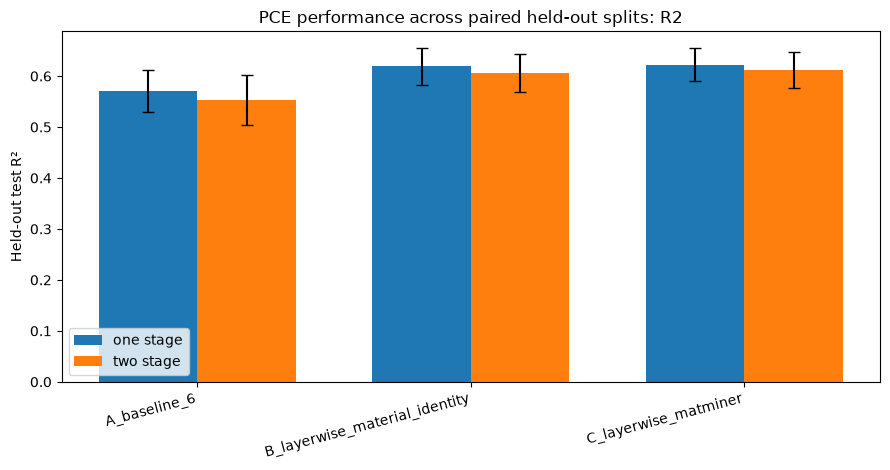

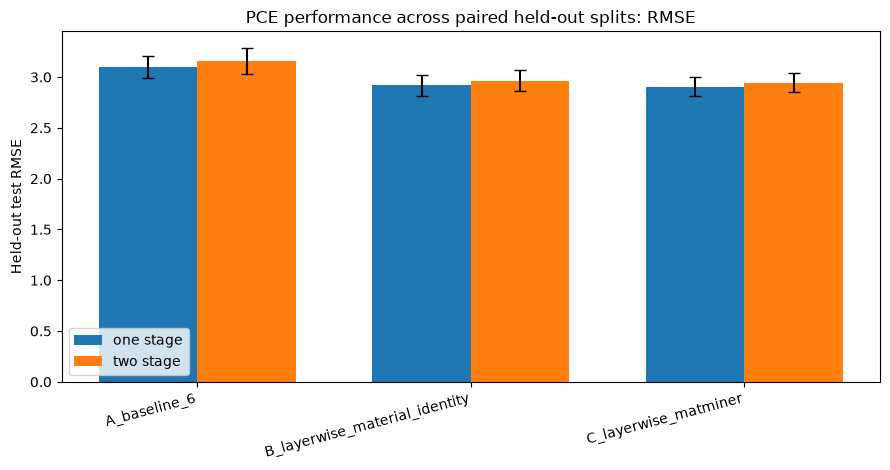

In [10]:

# ============================================================
# 9. Plot PCE performance
# ============================================================

model_order = [m for m in ["one_stage", "two_stage"] if m in pce_summary["model"].unique()]
feature_order = list(FEATURE_SETS.keys())

for metric, ylabel in [("R2", "Held-out test R²"), ("RMSE", "Held-out test RMSE")]:
    mean_column = f"{metric}_mean"
    std_column = f"{metric}_std"

    fig, ax = plt.subplots(figsize=(9, 4.8))
    x = np.arange(len(feature_order))
    width = 0.36 if len(model_order) > 1 else 0.55

    for model_index, model_name in enumerate(model_order):
        subset = (
            pce_summary[pce_summary["model"] == model_name]
            .set_index("feature_set")
            .reindex(feature_order)
        )
        offset = (model_index - (len(model_order) - 1) / 2) * width
        ax.bar(
            x + offset,
            subset[mean_column],
            width=width,
            yerr=subset[std_column],
            capsize=4,
            label=model_name.replace("_", " "),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(feature_order, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"PCE performance across paired held-out splits: {metric}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"pce_feature_expansion_{metric.lower()}.png", dpi=300)
    plt.show()


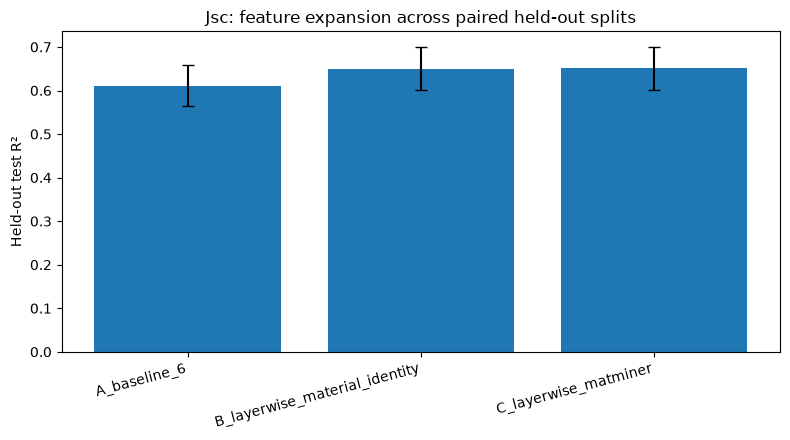

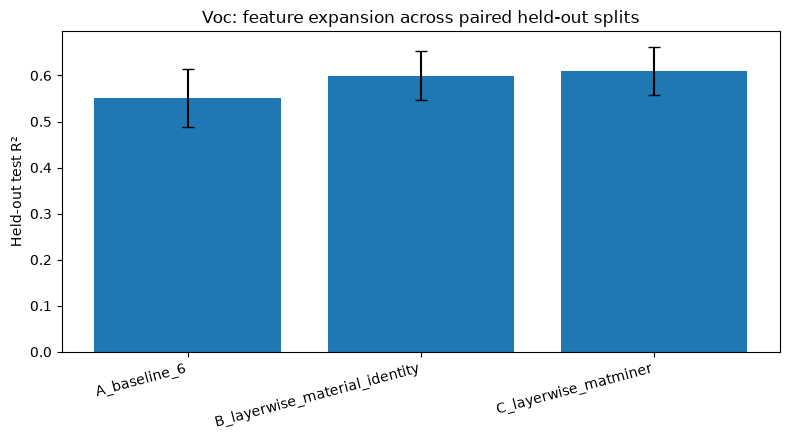

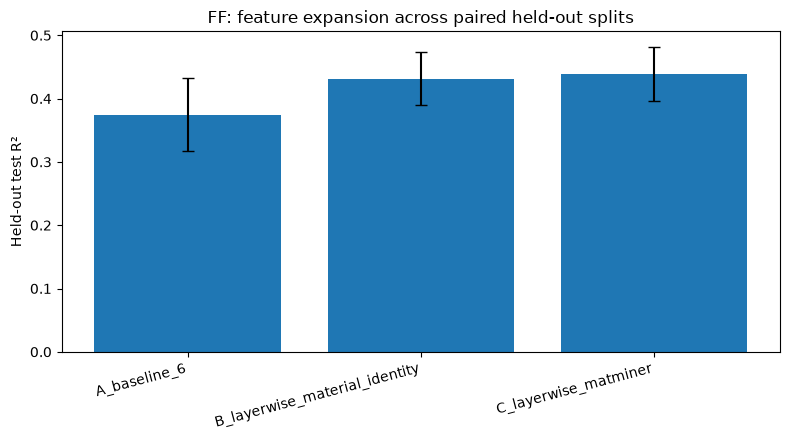

In [11]:

# ============================================================
# 10. Plot Stage-1 Jsc / Voc / FF performance
# ============================================================

for component_name in TARGETS:
    subset = (
        stage1_summary[stage1_summary["component"] == component_name]
        .set_index("feature_set")
        .reindex(feature_order)
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(feature_order))
    ax.bar(
        x,
        subset["R2_mean"],
        yerr=subset["R2_std"],
        capsize=4,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(feature_order, rotation=15, ha="right")
    ax.set_ylabel("Held-out test R²")
    ax.set_title(f"{component_name}: feature expansion across paired held-out splits")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{component_name.lower()}_feature_expansion_r2.png",
        dpi=300,
    )
    plt.show()
